In [1]:
pip uninstall sklearn --yes

Found existing installation: sklearn 0.0
Uninstalling sklearn-0.0:
  Successfully uninstalled sklearn-0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install pycaret

     |████████████████████████████████| 319 kB 291 kB/s            
     |████████████████████████████████| 114 kB 4.0 MB/s            
  Preparing metadata (setup.py) ... - done
     |████████████████████████████████| 6.8 MB 4.0 MB/s            
     |████████████████████████████████| 10.4 MB 69.3 MB/s            
     |████████████████████████████████| 167 kB 51.5 MB/s            
     |████████████████████████████████| 25.9 MB 914 kB/s             
     |████████████████████████████████| 16.5 MB 224 kB/s             
     |████████████████████████████████| 24.2 MB 824 kB/s             
     |████████████████████████████████| 636 kB 66.1 MB/s            
     |████████████████████████████████| 184 kB 36.8 MB/s            
     |████████████████████████████████| 1.0 MB 63.8 MB/s            
     |████████████████████████████████| 271 kB 47.4 MB/s            
     |████████████████████████████████| 14.8 MB 36.1 MB/s            
     |████████████████████████████████| 58 kB 3.8 MB/s  

# Titanic - Machine Learning from Disaster

# Table of Contents

*  [1) Introduction](#intro)

*  [2) Getting started](#gt)

*  [2) Creating a Custom Transformer](#cct)
    
*  [3) Creating a Pipeline](#cp)    

*  [4) Model Selection](#ms)

*  [5) Submission](#sub)

## 1) Introduction

Instead of aiming for a high score, this notebook describes how to create a Custom Transformer in an easy way and include it in the sklearn pipeline. I also wanted to share with you this topic that I just learned as a beginner.I hope you enjoy reviewing my notebook.

## 2) Getting Started

In [3]:
import numpy as np 
import pandas as pd 

pd.set_option('max_columns', None)
pd.set_option('max_rows', 90)
import warnings
warnings.filterwarnings('ignore')


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from pycaret.classification import *
from sklearn.preprocessing import OrdinalEncoder
import optuna


In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [5]:
train0 = pd.read_csv('/kaggle/input/titanic/train.csv')
test0 = pd.read_csv('/kaggle/input/titanic/test.csv')
submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [6]:
target = train0['Survived']
test_ids = test0['PassengerId']

train1 = train0.drop(['PassengerId','Survived','Ticket','Cabin','Name'], axis=1)
test1 = test0.drop(['PassengerId','Ticket','Cabin','Name'], axis=1)
data1 = train1.copy()
data1.info()
print(40*'-')
data1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB
----------------------------------------


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## 3) Creating a Custom Transformer

In [7]:
sibsp_x , parch_x = 2,3

class CombinedAttributes(BaseEstimator,TransformerMixin):
    
    def __init__(self,is_alone=True):
        self.is_alone = is_alone
        
    def fit(self,X,y=None):
        return self
        
    def transform(self,X,y=None):
        
        FamilyMembers = X[:,sibsp_x] + X[:,parch_x] + 1
        
        if self.is_alone:
            isAlone = np.where((X[:,sibsp_x]+X[:,parch_x])>=1,1,0)
            
            return np.c_[X,FamilyMembers,isAlone]
        else:
            
            return np.c_[X,FamilyMembers]

## 4) Creating Pipeline

In [8]:
titanic_num = data1.select_dtypes(include=['int64','float64']).columns
titanic_cat = data1.select_dtypes(include=['object']).columns

In [9]:
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

In [10]:
num_pipeline = Pipeline([
    ('imputer_num',imputer_num),
    ('combined',CombinedAttributes(is_alone=True)),
    ('std_scaler',StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer_cat',imputer_cat),
    ('encode',OrdinalEncoder())
])

full_pipeline = ColumnTransformer([
    ('num',num_pipeline,titanic_num),
    ('cat',cat_pipeline,titanic_cat),
])

In [11]:
columns = ['Pclass','Age', 'SibSp', 'Parch','Fare','FamilyMembers','isAlone','Sex', 'Embarked']

titanic_prepared= full_pipeline.fit_transform(data1)
titanic_prepared = pd.DataFrame(titanic_prepared,columns=columns)

titanic_test_prepared= full_pipeline.transform(test1)
titanic_test_prepared = pd.DataFrame(titanic_test_prepared,columns=columns)


## 4) Model Selection

In [12]:
 _ = setup(data = pd.concat([titanic_prepared,target],axis=1),target='Survived',silent=True)

,Description,Value
0,session_id,1655
1,Target,Survived
2,Target Type,Binary
3,Label Encoded,None
4,Original Data,"(891, 10)"
5,Missing Values,False
6,Numeric Features,7
7,Categorical Features,2
8,Ordinal Features,False
9,High Cardinality Features,False


In [13]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8508,0.8864,0.7654,0.8275,0.7932,0.6769,0.6802,0.0560
catboost,CatBoost Classifier,0.8492,0.8858,0.7522,0.8328,0.7880,0.6717,0.6758,0.9140
lightgbm,Light Gradient Boosting Machine,0.8379,0.8863,0.7433,0.8121,0.7751,0.6488,0.6513,0.1220
rf,Random Forest Classifier,0.8346,0.8837,0.7603,0.7904,0.7734,0.6435,0.6452,0.3130
xgboost,Extreme Gradient Boosting,0.8298,0.8819,0.7476,0.7901,0.7667,0.6331,0.6352,15.2780
ridge,Ridge Classifier,0.8154,0.0000,0.7056,0.7810,0.7386,0.5972,0.6013,0.0130
lda,Linear Discriminant Analysis,0.8138,0.8592,0.7056,0.7778,0.7369,0.5941,0.5983,0.0100
lr,Logistic Regression,0.8106,0.8582,0.7056,0.7711,0.7345,0.5883,0.5917,0.4960
ada,Ada Boost Classifier,0.8074,0.8363,0.7355,0.7491,0.7392,0.5869,0.5899,0.0590
et,Extra Trees Classifier,0.8026,0.8663,0.7264,0.7414,0.7317,0.5760,0.5777,0.2770


GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=100,
                           n_iter_no_change=None, presort='deprecated',
                           random_state=1655, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [14]:
gbc = create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8730,0.8793,0.7500,0.9000,0.8182,0.7219,0.7289
1,0.7778,0.8643,0.6667,0.7273,0.6957,0.5212,0.5224
2,0.8730,0.8766,0.7917,0.8636,0.8261,0.7264,0.7281
3,0.8548,0.8919,0.7391,0.8500,0.7907,0.6804,0.6843
4,0.8710,0.9660,0.8696,0.8000,0.8333,0.7284,0.7301
5,0.8710,0.8779,0.8696,0.8000,0.8333,0.7284,0.7301
6,0.8548,0.8829,0.7826,0.8182,0.8000,0.6862,0.6866
7,0.8226,0.8629,0.6522,0.8333,0.7317,0.6021,0.6122
8,0.8871,0.8445,0.7826,0.9000,0.8372,0.7514,0.7557


In [15]:
gbc_tuned = tune_model(gbc)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8571,0.8766,0.7083,0.8947,0.7907,0.6845,0.6952
1,0.8254,0.8697,0.7083,0.8095,0.7556,0.6207,0.6240
2,0.8889,0.8926,0.7917,0.9048,0.8444,0.7586,0.7627
3,0.8548,0.9091,0.7826,0.8182,0.8000,0.6862,0.6866
4,0.8548,0.9560,0.8261,0.7917,0.8085,0.6917,0.6921
5,0.8548,0.8612,0.8261,0.7917,0.8085,0.6917,0.6921
6,0.8710,0.8679,0.7826,0.8571,0.8182,0.7185,0.7203
7,0.7742,0.8428,0.6087,0.7368,0.6667,0.4983,0.5035
8,0.8548,0.8679,0.6957,0.8889,0.7805,0.6744,0.6858


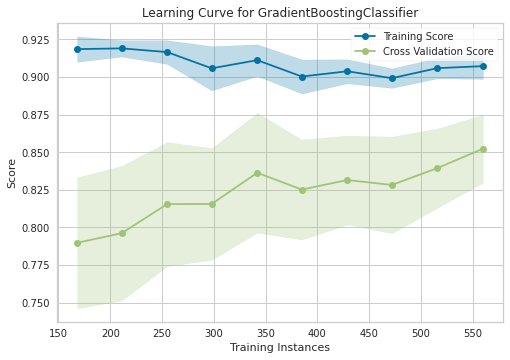

In [16]:
plot_model(estimator = gbc_tuned, plot = 'learning')

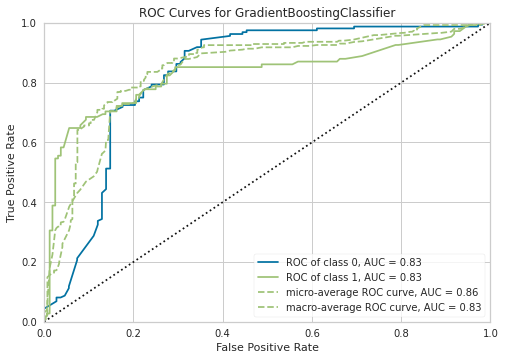

In [17]:
plot_model(estimator = gbc_tuned, plot = 'auc')

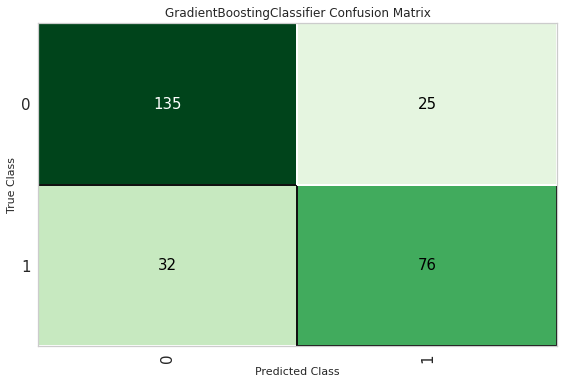

In [18]:
plot_model(estimator = gbc_tuned, plot = 'confusion_matrix')

In [19]:
evaluate_model(gbc_tuned)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [20]:
predictions = predict_model(gbc_tuned, titanic_test_prepared)

## 5) Submission

In [21]:
submission['Survived'] = round(predictions['Label'].astype(float).astype(int))
submission.to_csv('submission.csv',index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Thank you for checking my notebook, I will be glad to share your thoughts.